# QGA vs CC

Based on input `input_qga_vs_cc.yaml` and the generated outputs in directories `uqcm_wom.20.09.2024` and `cc.20.09.2024`.

To generate the outputs run the following script in the command line. This assumes your are running from hte `QGA` directory in a Python environment that has all dependencies installed.

```python src/qga_toolbox/qga_simulator.py inputs/input_qga_vs_cc.yaml```

! Warning: this may take a while. If you want to do a quicker analysis you can lower the number of problem instances considered in the `problem-instance-number` attribute, use that number in the `max_problem` variable below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

Define a function to load the fidelity arrays easily.

In [2]:
def load_fidelity_array(i_prob, i_state, alg_name):

    dir_path = os.path.join(os.path.dirname(os.getcwd()), 'outputs',f'{alg_name}.20.09.2024')
    
    return  np.load(os.path.join(dir_path, f'problem_{i_prob}_state_{i_state}_individual_eig_fidelity.npy'))

## Distribution of the final fidelity

We load the final fidelity (fidelity after the last sort operation).

In [3]:
max_problem = 200
max_states = 3  # Originally 10 states where used

final_fid_dict = {
    'uqcm_wom': np.zeros((max_problem, max_states)),
    'cc': np.zeros((max_problem, max_states))
    }

for i_prob in range(max_problem):
    for i_state in range(max_states):
        for algname in ['uqcm_wom', 'cc']:
            fidarr = load_fidelity_array(i_prob, i_state, algname)
    
            # The indexing of the fidelity array is
            #     (generation-step, individual, eigenstate)
            # -4 corresponds to the state after the last sorting operation
            final_fid_dict[algname][i_prob, i_state] = fidarr[-4,0,0]
    
# Average over the initial populations
final_fid_av = {variant: np.mean(final_fid, axis=1) for variant, final_fid in final_fid_dict.items()}
    

Define the function for the jittering plot.

In [4]:
def jittering_plot(list_of_arrays, labels, jittering_variance = 1, constant_displacement=1, dy=0.1):
    plt.figure(figsize=(10, 6))
    
    for i, data in enumerate(list_of_arrays):
        # Calculate the number of points in each interval (y, y+dy)
        y_vals = np.array(data)
        intervals = np.arange(np.min(y_vals), np.max(y_vals), dy)
        densities = np.array([np.sum((y_vals >= interval) & (y_vals < interval + dy)) for interval in intervals])
        
        # Generate the x-values with jitter
        jitter = []
        for y in y_vals:
            density_index = np.digitize(y, intervals) - 1
            jitter.append(np.random.normal(loc=0, scale=jittering_variance * densities[density_index]/len(y_vals) * constant_displacement))
        
        x_vals = np.array(jitter) + i * constant_displacement
        
        plt.scatter(x_vals, y_vals, alpha=0.6, label=labels[i])
    
    plt.xlim(-constant_displacement, len(list_of_arrays) * constant_displacement)
    plt.xticks(ticks=np.arange(len(labels)) * constant_displacement, labels=labels)
    plt.xlabel('QGA variant')
    plt.ylabel('Final fidelities')
    plt.grid(True)
    plt.show()

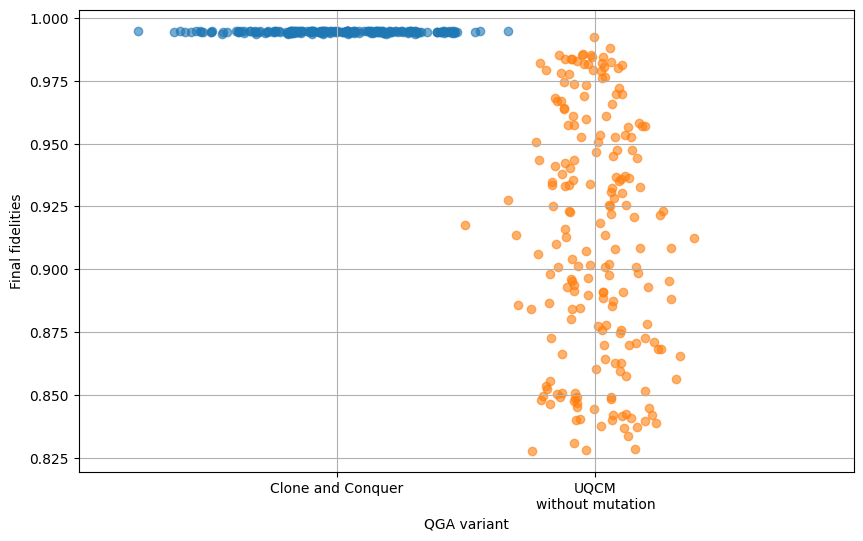

In [5]:
jittering_plot([final_fid_av['cc'], final_fid_av['uqcm_wom']],
               ['Clone and Conquer', 'UQCM\nwithout mutation'],
               jittering_variance=.25)

We can see that there is a linear relation between them.

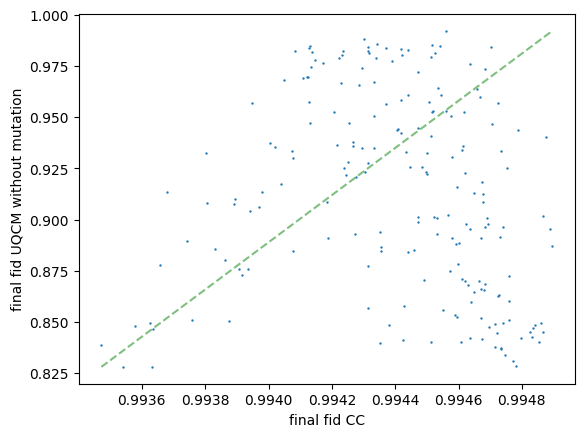

In [6]:
plt.scatter(final_fid_av['cc'],
            final_fid_av['uqcm_wom'],
            s=.5)
plt.plot([np.min(final_fid_av[f'cc']), np.max(final_fid_av['cc'])],
            [np.min(final_fid_av[f'uqcm_wom']), np.max(final_fid_av['uqcm_wom'])],
            linestyle='--',
            color='g',
            alpha=.5)

plt.xlabel('final fid CC')
plt.ylabel('final fid UQCM without mutation')
plt.show()

## Sample evolution for some Hamiltonian

The plot for the variants for mutation if fundamentally different because the mutations here were simulated with the full quantum channel instead of sampling random unitaries.

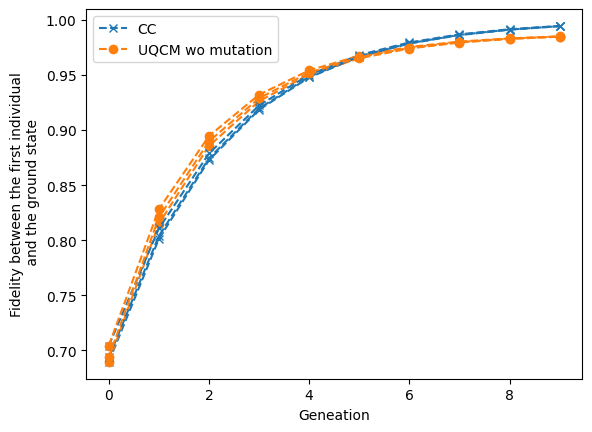

In [8]:
problem_instance = 0

for i in range(max_states):
    fidarr_wm = load_fidelity_array(problem_instance, i, 'cc')
    fidarr_wom = load_fidelity_array(problem_instance, i, 'uqcm_wom')
    plt.plot(fidarr_wm[1::4,0,0], marker='x', linestyle='--', color='C0', label='CC')
    plt.plot(fidarr_wom[1::4,0,0], marker='o', linestyle='--', color='C1', label='UQCM wo mutation')

plt.ylabel('Fidelity between the first individual\n and the ground state')
plt.xlabel('Geneation')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='x', linestyle='--', color='C0', label='CC'),
    plt.Line2D([0], [0], marker='o', linestyle='--', color='C1', label='UQCM wo mutation')
])

plt.show()

# Can a combination of both accelerate convergence?

Let's say, we first run the QGA until reaching a threshold or convergence and then switch to CC for refinement.

To emulate the CC part we will infer the convergence ratio of that run.

Let us model the evolution of fidelity for QGA and CC respectively as
$$
f_{QGA}(t)=a-\lambda^t (1-c)
$$

$$
f_{CC}(t)=1-\gamma^t (1-c)
$$

Assuming $a<1$ and $\lambda <\gamma$, it seems reasonable to combine them in the following way

$$
f_T(t) = 
\begin{cases}
a-\lambda^t (1-c) & t < T\\
1-\gamma^t (1-f_{QGA}(T)) & t \geq T
\end{cases}
$$

Then, given a desired error threshold $\varepsilon$ what is the optimal $T$ that minimizes the time $t_*$ such that $\varepsilon \geq 1-f_T(t_*)$?

Assuming $1-a > \varepsilon$ and solving for $t_*$:

$$
t_*
=
T+\frac{\ln\varepsilon - \ln(1-a+\lambda^T(1-c))}{\ln \gamma}
$$

Whose minimum can be found at

$$
1-\frac{\ln\lambda}{\ln\gamma}
    \frac{1-c}{1-a+\lambda^T (1-c)}
    \lambda^T = 0
$$

$$
(1-a+\lambda^T (1-c))
-\frac{\ln\lambda}{\ln\gamma}(1-c)\lambda^T = 0
$$

$$
(1-a)+
\left(1- \frac{\ln\lambda}{\ln\gamma}\right) (1-c) \lambda^T = 0
$$

$$
\lambda^T =
\frac{(1-a)}{
\left(\frac{\ln\lambda}{\ln\gamma}-1\right) (1-c) }
$$

$$
T = \frac{1}{\ln\lambda}\ln\left(
\frac{(1-a)}{
\left(\frac{\ln\lambda}{\ln\gamma}-1\right) (1-c) }\right)
$$

The idea is to find this $T$ for each case and see if it is positive and how much it accelerates convergence. If $\lambda < \gamma$ is not satisfied then $T=0$.

$\varepsilon$ doesn't play a role? Maybe just the condition on $a$?

In [9]:
from scipy import stats

In [33]:
def warmup_period_from_params(a, c, gamma, lamb):

    if gamma <= lamb:
        return 0
    else:
        T = 1/np.log(lamb) * np.log((1-a) / (np.log(lamb)/np.log(gamma) - 1) / (1-c))

        if T <= 0:
            return 0
        else:
            return T

def warmup_period(f_qga,f_cc, get_params = False):
    t = np.arange(len(f_qga))

    # From a single paths
    # extract the parameters
    a = f_qga[-1] + 1e-6

    result_qga = stats.linregress(t, np.log(a-f_qga))
    lamb = np.exp(result_qga.slope)
    result_cc = stats.linregress(t, np.log(1-f_cc))
    gamma = np.exp(result_cc.slope)

    # From the parameters get T
    dim = 4
    if get_params:
        return warmup_period_from_params(a, 1/dim, gamma, lamb), a, gamma, lamb
    else:
        return warmup_period_from_params(a, 1/dim, gamma, lamb)


In [34]:
t_arr = np.zeros(max_problem)
a_arr = np.zeros(max_problem)
gamma_arr = np.zeros(max_problem)
lamb_arr = np.zeros(max_problem)

for p in range(max_problem):
    fidarr_cc = load_fidelity_array(p, 0, 'cc')[1::4,0,0]
    fidarr_qga = load_fidelity_array(p, 0, 'uqcm_wom')[1::4,0,0]

    t_arr[p], a_arr[p], gamma_arr[p], lamb_arr[p] = warmup_period(fidarr_qga, fidarr_cc, True)

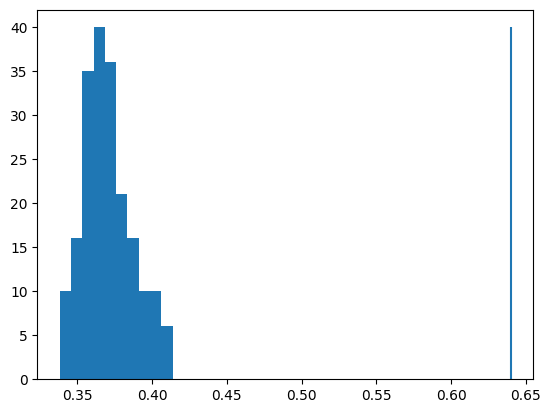

In [37]:
plt.hist(lamb_arr)
plt.vlines(np.mean(gamma_arr), 0, 40)

(array([92., 51., 25., 25.,  7.]),
 array([1.69067743, 2.28180094, 2.87292444, 3.46404794, 4.05517144,
        4.64629494]),
 <BarContainer object of 5 artists>)

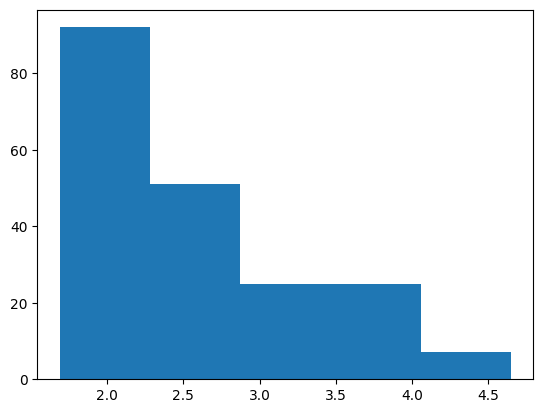

In [39]:
plt.hist(t_arr, bins=5)